In [1]:
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
X = torch.randn(200,2)
y = (X[:,0]+X[:,1] > 0).float().view(-1,1)

In [3]:
class NN(nn.Module):
    def __init__(self,act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,8),
            act,
            nn.Linear(8,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)


In [4]:
def train(lr,act):
    model = NN(act)
    opt = optim.SGD(model.parameters(),lr)
    loss_fn = nn.BCELoss()
    losses=[]
    for _ in range(50):
        opt.zero_grad()
        loss = loss_fn(model(X),y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

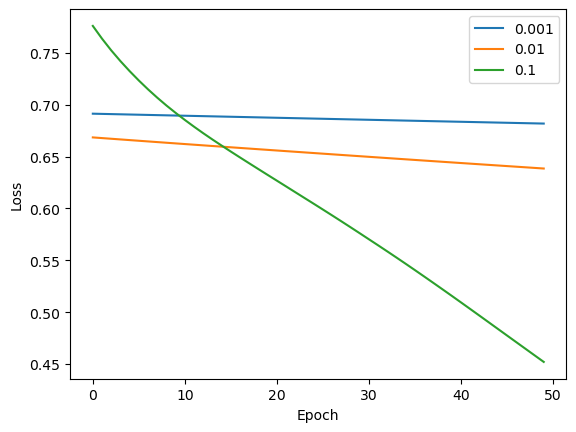

In [7]:
for lr in [0.001,0.01,0.1]:
    plt.plot(train(lr,nn.ReLU()), label=lr)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

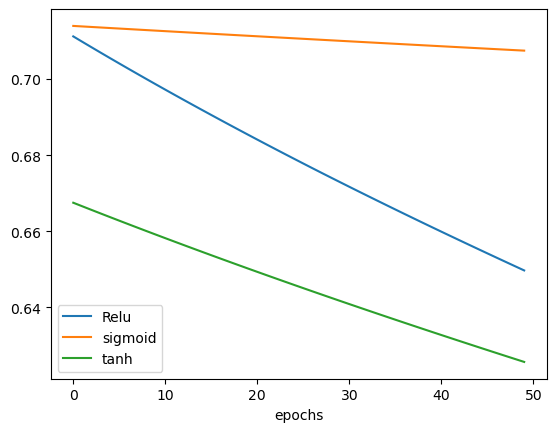

In [11]:
for name,act in [("Relu",nn.ReLU()), ("sigmoid",nn.Sigmoid()), ("tanh",nn.Tanh())]:
    plt.plot(train(0.01,act),label=name)
    plt.xlabel('epochs')
    plt.legend()